# 03 — Data Visualization
**Goal:** Understand patterns in the data through 7 charts.

Input : `data/clean_data.csv`  
Output: `data/viz_01_*.png` through `data/viz_07_*.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows ')

Loaded 806 rows 


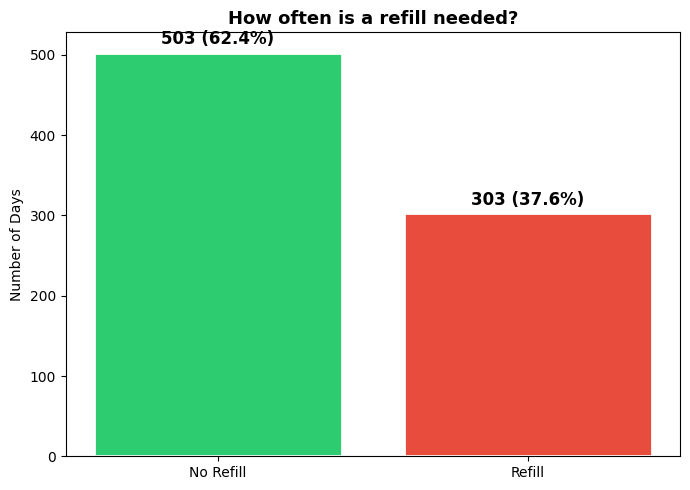

In [2]:
# ── Chart 1: Class Distribution (Refill vs No Refill) ──────────
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['Target'].value_counts().sort_index()
labels = ['No Refill', 'Refill']
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.set_title('How often is a refill needed?', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Days')
plt.tight_layout()
plt.savefig('../data/viz_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


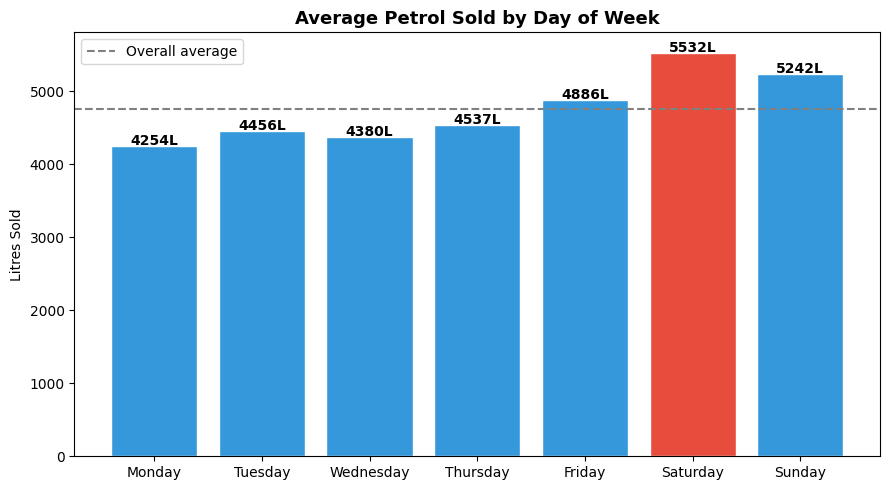

In [3]:
# ── Chart 2: Average Sales by Day of Week ─────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_by_day = df.groupby('Day')['Total_Sold'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v == avg_by_day.max() else '#3498db' for v in avg_by_day]
bars = ax.bar(avg_by_day.index, avg_by_day.values, color=colors, edgecolor='white')
for bar, val in zip(bars, avg_by_day.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f}L', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Petrol Sold by Day of Week', fontweight='bold', fontsize=13)
ax.set_ylabel('Litres Sold')
ax.axhline(avg_by_day.mean(), color='gray', linestyle='--', label='Overall average')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_02_sales_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

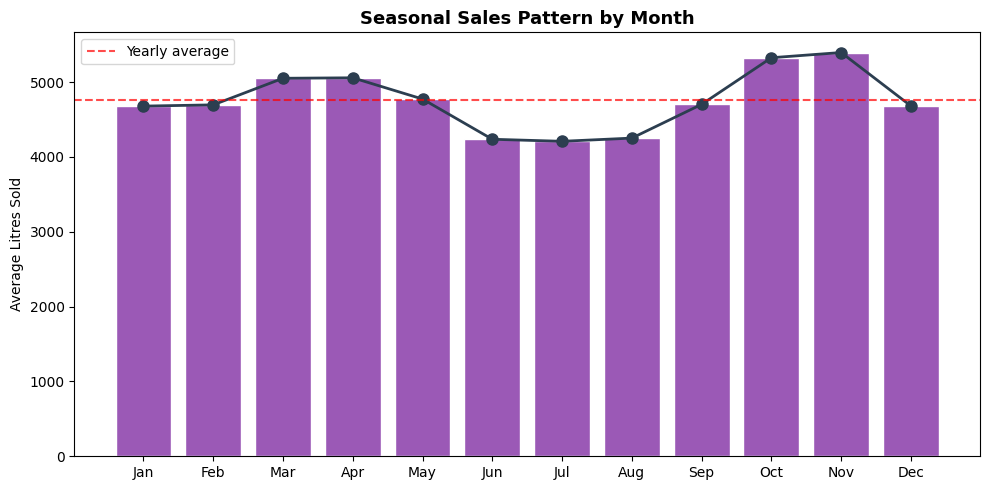

In [4]:
# ── Chart 3: Average Sales by Month (Seasonal Pattern) ────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
avg_by_month = df.groupby('Month')['Total_Sold'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, avg_by_month.values, color='#9b59b6', edgecolor='white')
ax.plot(month_names, avg_by_month.values, color='#2c3e50',
        marker='o', linewidth=2, markersize=8)
ax.set_title('Seasonal Sales Pattern by Month', fontweight='bold', fontsize=13)
ax.set_ylabel('Average Litres Sold')
ax.axhline(avg_by_month.mean(), color='red', linestyle='--', alpha=0.7, label='Yearly average')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_03_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

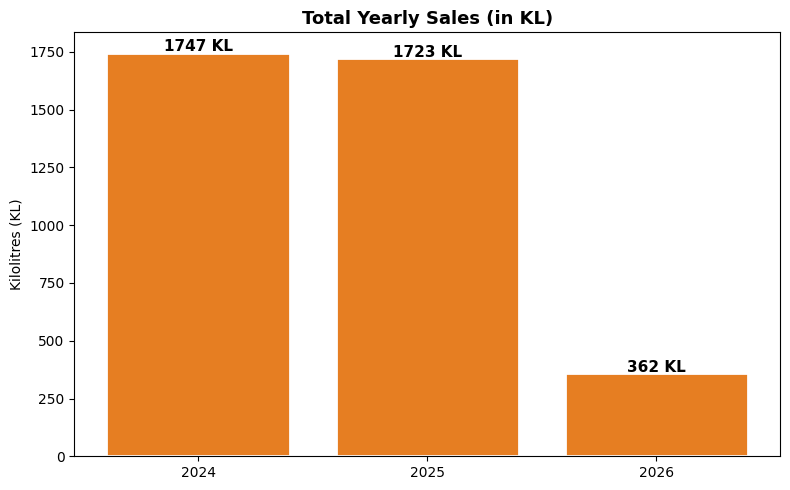

In [5]:
# ── Chart 4: Yearly Sales Growth ──────────────────────────────
yearly = df.groupby('Year')['Total_Sold'].sum() / 1000  # Convert to KL

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values,
              color='#e67e22', edgecolor='white', linewidth=2)
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f} KL', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Total Yearly Sales (in KL)', fontweight='bold', fontsize=13)
ax.set_ylabel('Kilolitres (KL)')
plt.tight_layout()
plt.savefig('../data/viz_04_yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()

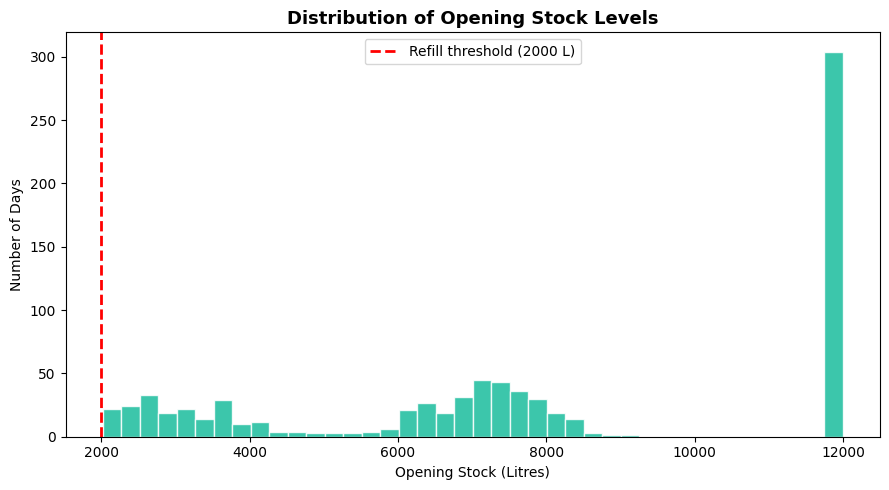

In [6]:
# ── Chart 5: Opening Stock Distribution ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Opening_Stock'], bins=40, color='#1abc9c',
        edgecolor='white', alpha=0.85)
ax.axvline(2000, color='red', linestyle='--', linewidth=2,
           label='Refill threshold (2000 L)')
ax.set_title('Distribution of Opening Stock Levels', fontweight='bold', fontsize=13)
ax.set_xlabel('Opening Stock (Litres)')
ax.set_ylabel('Number of Days')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_05_opening_stock.png', dpi=150, bbox_inches='tight')
plt.show()

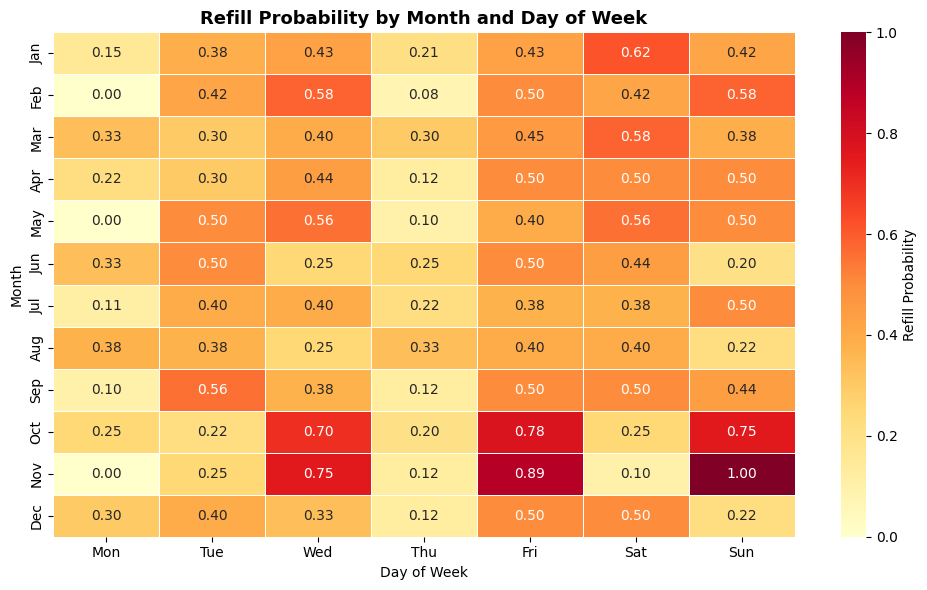

In [7]:
# ── Chart 6: Refill Heatmap (Month vs Day of Week) ─────────────
pivot = df.pivot_table(values='Target', index='Month', columns='DayOfWeek', aggfunc='mean')
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Refill Probability'})
ax.set_title('Refill Probability by Month and Day of Week', fontweight='bold', fontsize=13)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('../data/viz_06_refill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

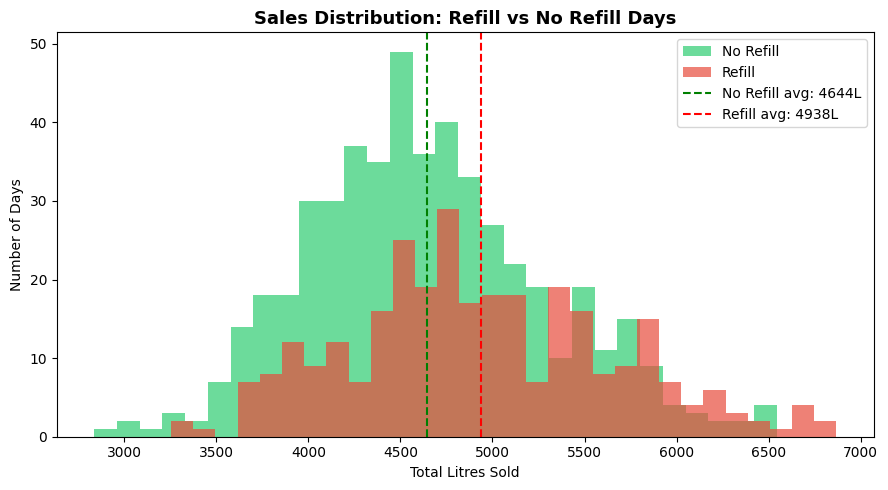

In [8]:
# ── Chart 7: Sales Distribution (Refill vs No Refill days) ────
fig, ax = plt.subplots(figsize=(9, 5))
no_refill = df[df['Target'] == 0]['Total_Sold']
refill    = df[df['Target'] == 1]['Total_Sold']

ax.hist(no_refill, bins=30, alpha=0.7, color='#2ecc71', label='No Refill')
ax.hist(refill,    bins=30, alpha=0.7, color='#e74c3c', label='Refill')
ax.axvline(no_refill.mean(), color='green', linestyle='--',
           label=f'No Refill avg: {no_refill.mean():.0f}L')
ax.axvline(refill.mean(), color='red', linestyle='--',
           label=f'Refill avg: {refill.mean():.0f}L')
ax.set_title('Sales Distribution: Refill vs No Refill Days', fontweight='bold', fontsize=13)
ax.set_xlabel('Total Litres Sold')
ax.set_ylabel('Number of Days')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_07_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()